# Spatial and temporal homogeneity — data/MC

Inspect whether data–MC agreement is uniform in:

1. **Spatial** octants of the detector (slice vertex position)
2. **Temporal** chunks of the beam run (15 time-ordered slices; MC re-scaled to each chunk's POT)

Variables: **`muon-dir_phi`**, **`tki-del_Tp`**.

For **`muon-dir_phi`**, the syst. band uses **`muon-dir_x`** from `category_syst_summary.npz` (same 20 bins).

Plots follow `data_mc_comparison.ipynb` (`overlay_hists`, topology breakdown, intime subtraction, category syst bands). Panel grids use at most **4 columns** per row.

In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
from os import path, makedirs
from datetime import datetime
from functools import partial
import contextlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.append('/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana')
from pyanalib.split_df_helpers import load_dfs
from pyanalib.split_df_helpers_new import dfs_from_dir
from analysis_village.numucc_1p0pi.variable_configs import VariableConfig
from analysis_village.numucc_1p0pi.utils import *
from analysis_village.numucc_1p0pi.files_config import *

plt.style.use("presentation.mplstyle")

In [ ]:
# --- paths (same as data_mc_comparison.ipynb) ---
DFS_ROOT = "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs"
QUALITY_DF_DIR = path.join(DFS_ROOT, "2026_05_16_230705__sel_mup-data-1e20/merged_perTPC")
QUALITY_DF_PATH = path.join(QUALITY_DF_DIR, "beam_data_1e20_qualitycut.df")

DIR_MC = path.join(DFS_ROOT, "2026_05_11_084007__sel_mup-wgts_mcstat/merged_perTPC")
DIR_INTIME = path.join(DFS_ROOT, "2026_05_11_083624__sel_mup-mc-Intime/merged_perTPC")
DIR_OFFBEAM = path.join(DFS_ROOT, "2026_05_11_040015__sel_mup-data-OffBeamLight/merged_perTPC")

KEYS2LOAD = ["hdr", "evt"]
N_MAX_CONCAT = 999

save_fig = True
today_str = datetime.now().strftime("%Y%m%d")
save_fig_dir = path.join(save_fig_base_dir, f"homogeneity_{today_str}")
if save_fig and not path.exists(save_fig_dir):
    makedirs(save_fig_dir)
print("quality-cut df:", QUALITY_DF_PATH)
print("saving plots in", save_fig_dir)

## Load MC, intime, and beam-quality data

In [ ]:
mc_dfs = dfs_from_dir(DIR_MC, filename_str="sel_mup-wgts_mcstat", keys2load=KEYS2LOAD, n_max_concat=N_MAX_CONCAT)
intime_dfs = dfs_from_dir(DIR_INTIME, filename_str="sel_mup-mc-Intime", keys2load=KEYS2LOAD, n_max_concat=N_MAX_CONCAT)
offbeam_dfs = dfs_from_dir(DIR_OFFBEAM, filename_str="sel_mup-data-OffBeamLight", keys2load=KEYS2LOAD, n_max_concat=N_MAX_CONCAT)

mc_evt_df = mc_dfs["evt"]
mc_hdr_df = mc_dfs["hdr"]
intime_evt_df = intime_dfs["evt"]
intime_hdr_df = intime_dfs["hdr"]
offbeam_evt_df = offbeam_dfs["evt"]
offbeam_hdr_df = offbeam_dfs["hdr"]

mc_evt_df.loc[mc_evt_df.mc.iscc.isna(), ("mc", "iscc")] = 999

quality_dfs = load_dfs(QUALITY_DF_PATH, keys2load=["hdr", "trigger", "evt_good"], n_max_concat=1)
data_evt_df = quality_dfs["evt_good"]
data_hdr_df = quality_dfs["hdr"].join(quality_dfs["trigger"])
data_evt_df[("mc", "iscc")] = 999

data_tot_pot = data_hdr_df["pot"].sum() * 0.98
data_gates = data_hdr_df.nbnbinfo.sum()

pot_str = get_pot_str(data_tot_pot)
pot_label = f"Events / Bin (POT={pot_str})"

data_evt_df["pot_weight"] = np.ones(len(data_evt_df))
mc_tot_pot = mc_hdr_df["pot"].sum()
mc_pot_scale = data_tot_pot / mc_tot_pot
mc_evt_df["pot_weight"] = mc_pot_scale * np.ones(len(mc_evt_df))

intime_gates = offbeam_hdr_df[offbeam_hdr_df["first_in_subrun"] == 1]["noffbeambnb"].sum()
f = 0.0753
scale_intime_to_lightdata = (1 - f) * data_gates / intime_gates
intime_evt_df["pot_weight"] = scale_intime_to_lightdata * np.ones(len(intime_evt_df))

print(f"evt_good: {len(data_evt_df):,}  mc: {len(mc_evt_df):,}  intime: {len(intime_evt_df):,}")

In [138]:
perTPC_inset = 10

def perTPC_cut(df):
    in_TPC1 = (
        InFV(df.slc.vertex, det="SBND_TPC1", incathode=perTPC_inset)
        & InFV(df.mu.pfp.trk.end, det="SBND_TPC1", incathode=perTPC_inset)
        & InFV(df.p.pfp.trk.end, det="SBND_TPC1", incathode=perTPC_inset)
    )
    in_TPC2 = (
        InFV(df.slc.vertex, det="SBND_TPC2", incathode=perTPC_inset)
        & InFV(df.mu.pfp.trk.end, det="SBND_TPC2", incathode=perTPC_inset)
        & InFV(df.p.pfp.trk.end, det="SBND_TPC2", incathode=perTPC_inset)
    )
    return in_TPC1 | in_TPC2

mc_evt_df = mc_evt_df.loc[perTPC_cut(mc_evt_df)]
intime_evt_df = intime_evt_df.loc[perTPC_cut(intime_evt_df)]

for df in (mc_evt_df, data_evt_df, intime_evt_df):
    df[("mu", "pfp", "trk", "phi", "", "", "")] = np.degrees(
        np.arctan2(
            df[("mu", "pfp", "trk", "dir", "x", "", "")],
            df[("mu", "pfp", "trk", "dir", "y", "", "")],
        )
    )
    df[("p", "pfp", "trk", "phi", "", "", "")] = np.degrees(
        np.arctan2(
            df[("p", "pfp", "trk", "dir", "x", "", "")],
            df[("p", "pfp", "trk", "dir", "y", "", "")],
        )
    )

print(f"perTPC: data={len(data_evt_df):,} mc={len(mc_evt_df):,} intime={len(intime_evt_df):,}")

perTPC: data=12,804 mc=54,287 intime=96


In [139]:
from pyanalib.variable_calculator import get_cc1p0pi_tki
from pyanalib.pandas_helpers import pad_column_name

def evt_df_fixed(df):
    slc_mudf = df.mu.pfp.trk
    slc_pdf = df.p.pfp.trk
    tki_reco = get_cc1p0pi_tki(
        slc_mudf,
        slc_pdf,
        pad_column_name(('P', 'p_muon'), slc_mudf),
        pad_column_name(('P', 'p_proton'), slc_pdf),
    )
    df['del_Tp_x'] = tki_reco['del_Tp_x']
    df['del_Tp_y'] = tki_reco['del_Tp_y']

    mc_mudf = df.mu.pfp.trk.truth.p
    mc_pdf = df.p.pfp.trk.truth.p
    tki_mc = get_cc1p0pi_tki(
        mc_mudf,
        mc_pdf,
        pad_column_name(('totp',), mc_mudf),
        pad_column_name(('totp',), mc_pdf),
    )
    df['mc_del_Tp_x'] = tki_mc['del_Tp_x']
    df['mc_del_Tp_y'] = tki_mc['del_Tp_y']
    df[('mc', 'del_Tp_x')] = tki_mc['del_Tp_x']
    df[('mc', 'del_Tp_y')] = tki_mc['del_Tp_y']

    df = df[np.abs(df.slc.vertex.x) > 10]
    if 'topo_categ' not in df.columns:
        df = df.copy()
        df.loc[:, 'topo_categ'] = get_topo_category(df)
    return df

mc_evt_df = evt_df_fixed(mc_evt_df)
data_evt_df = evt_df_fixed(data_evt_df)
intime_evt_df = evt_df_fixed(intime_evt_df)

/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/envs/venv_py310_cafpyana/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in arccos
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/ipykernel_672454/1854980404.py:26: PerformanceWarning: indexing past lexsort depth may impact performance.
  df[('mc', 'del_Tp_x')] = tki_mc['del_Tp_x']
/tmp/ipykernel_672454/1854980404.py:27: PerformanceWarning: indexing past lexsort depth may impact performance.
  df[('mc', 'del_Tp_y')] = tki_mc['del_Tp_y']


In [140]:
from pathlib import Path
from analysis_village.numucc_1p0pi.dataset_locations import PLOTS_BASE
from analysis_village.numucc_1p0pi.syst_disk_layout import category_summary_npz_path

SYST_DISK_ROOT = "/exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final"
CATEGORY_SUMMARY_OUT = (
    Path(PLOTS_BASE) / "syst_uncertainty_breakdown" / "final_selected" / "category_syst_summary.npz"
)
CATEGORY_SUMMARY_NPZ = category_summary_npz_path(SYST_DISK_ROOT)
if not path.isfile(CATEGORY_SUMMARY_NPZ) and CATEGORY_SUMMARY_OUT.is_file():
    CATEGORY_SUMMARY_NPZ = str(CATEGORY_SUMMARY_OUT)

import os
os.environ["NUMUCC_SYST_DISK_ROOT"] = SYST_DISK_ROOT
OVERLAY_SYST_KIND = "rate"

VAR_CONFIGS = [
    VariableConfig.muon_direction_phi(),
    # VariableConfig.muon_direction(),
    # VariableConfig.tki_del_Tp(),
    # VariableConfig.neutrino_energy(),
]
BREAKDOWN_TYPE = "topology"
PANEL_COLS_MAX = 4
FOM_POT_SCALE = 0.98

# Per-panel physical size (inches) — overlay_hists legends are sized for ~8.5" axes
PANEL_COL_W_IN = 8.0
PANEL_ROW_H_IN = 7.2
HOMOGENEITY_GRIDSPEC = {"hspace": 0.30, "wspace": 0.28}

ratio = True
approval = "internal"
textloc = [0.03, 0.55]
ax_ylim_ratio = 1.9


def make_data_vs_mc_plotter(var_config, mc_df, intime_df):
    return partial(
        overlay_hists,
        mc_df=mc_df,
        intime_df=intime_df,
        dirt_df=None,
        ax_ylim_ratio=ax_ylim_ratio,
        ratio=ratio,
        textloc=textloc,
        approval=approval,
        save_fig=False,
        plot=False,
        syst=None,
        syst_kind=OVERLAY_SYST_KIND,
        syst_disk_root=SYST_DISK_ROOT,
        category_syst_summary_path=CATEGORY_SUMMARY_NPZ,
        load_syst_from_summary=True,
        breakdown_type=BREAKDOWN_TYPE,
        var_config=var_config,
    )


def mc_intime_for_chunk_pot(hdr_chunk, mc_df, intime_df):
    """Scale MC (and intime) pot_weight to match chunked data exposure."""
    chunk_pot = hdr_chunk["pot"].sum() * FOM_POT_SCALE
    chunk_gates = hdr_chunk.nbnbinfo.sum()
    mc_scaled = mc_df.copy()
    mc_scaled["pot_weight"] = (chunk_pot / mc_tot_pot) * np.ones(len(mc_scaled))
    intime_scaled = intime_df.copy()
    intime_scaled["pot_weight"] = (
        (1 - f) * chunk_gates / intime_gates * np.ones(len(intime_scaled))
    )
    return mc_scaled, intime_scaled, chunk_pot

## Helpers: octant labels, time chunks, multi-panel overlays

**Octant planes** at $(x_0, y_0, z_0) = (0, 0, 250)$ cm using slice vertex $(x,y,z)$:

- East: $x < 0$; West: $x > 0$
- Top: $y > 0$; Bottom: $y < 0$
- South: $z < 250$; North: $z > 250$

In [141]:
_X0, _Y0, _Z0 = 0.0, 0.0, 250.0

# Grid fill order: top row = y > 0 (Top), bottom row = y < 0 (Bottom)
_OCTANT_LABELS = [
    "E-S-Top", "E-N-Top", "W-S-Top", "W-N-Top",
    "E-S-Bottom", "E-N-Bottom", "W-S-Bottom", "W-N-Bottom",
]


def add_sbnd_octant_labels(df, x0=_X0, y0=_Y0, z0=_Z0):
    x = df.slc.vertex.x.astype(float)
    y = df.slc.vertex.y.astype(float)
    z = df.slc.vertex.z.astype(float)

    ew = np.where(x < x0, "E", "W")
    ns = np.where(z < z0, "S", "N")
    tb = np.where(y > y0, "Top", "Bottom")
    octant = np.char.add(np.char.add(np.char.add(ew, "-"), np.char.add(ns, "-")), tb)

    out = df.copy()
    out[("sbnd", "octant", "ew", "", "", "", "")] = ew
    out[("sbnd", "octant", "ns", "", "", "", "")] = ns
    out[("sbnd", "octant", "tb", "", "", "", "")] = tb
    out[("sbnd", "octant", "octant", "", "", "", "")] = pd.Categorical(
        octant, categories=_OCTANT_LABELS, ordered=True
    )
    return out


def octant_mask(df, oct_label):
    return df["sbnd"].octant.octant.astype(str) == oct_label


print_sbnd_octant_vertex_ranges(_X0, _Y0, _Z0)

data_evt_df = add_sbnd_octant_labels(data_evt_df)
mc_evt_df = add_sbnd_octant_labels(mc_evt_df)
intime_evt_df = add_sbnd_octant_labels(intime_evt_df)


=== SBND octants vs reco vertex [cm]; planes x=0, y=0, z=250 ===
  E/W (TPC sides):  E if x < 0 (negative x),    W if x >= 0
  N/S:              S if z < 250 (lower z),    N if z >= 250
  Top / Bottom:     Bottom if y < 0,    Top if y >= 0

octant                   x range                     z range                     y range          
 ----------------------------------------------------------------------------------------------------
W-S-Bottom              [0, +inf)                  (-inf, 250)                  (-inf, 0)         
W-S-Top                 [0, +inf)                  (-inf, 250)                  [0, +inf)         
W-N-Bottom              [0, +inf)                  [250, +inf)                  (-inf, 0)         
W-N-Top                 [0, +inf)                  [250, +inf)                  [0, +inf)         
E-S-Bottom              (-inf, 0)                  (-inf, 250)                  (-inf, 0)         
E-S-Top                 (-inf, 0)                  (-inf, 250)

In [142]:
@contextlib.contextmanager
def _patch_overlay_axes(fig, ax_rate, ax_ratio):
    # Draw overlay_hists on pre-allocated axes (rate + ratio panels).
    _orig_subplots = plt.subplots
    _orig_close = plt.close

    def _subplots(*args, **kwargs):
        if kwargs.get("gridspec_kw") is not None:
            return fig, [ax_rate, ax_ratio]
        return fig, ax_rate

    def _close(_fig=None):
        return None

    plt.subplots = _subplots
    plt.close = _close
    try:
        yield
    finally:
        plt.subplots = _orig_subplots
        plt.close = _orig_close


def homogeneity_figsize(n_row_panels, n_cols):
    return (PANEL_COL_W_IN * n_cols, PANEL_ROW_H_IN * n_row_panels)


def _style_homogeneity_axes(ax_rate, ax_ratio):
    ax_rate.tick_params(axis="both", labelsize=11)
    ax_ratio.tick_params(axis="both", labelsize=11)
    leg = ax_rate.get_legend()
    if leg is not None:
        for txt in leg.get_texts():
            txt.set_fontsize(8)
        if hasattr(leg, "set_ncols"):
            leg.set_ncols(2)
        leg.set_bbox_to_anchor((0.02, 0.98))
    # for txt in list(ax_rate.texts):
        # if "GENIE" in txt.get_text():
            # txt.remove()


def draw_overlay_panel(
    fig, ax_rate, ax_ratio, var_config, plotter,
    data_df, mc_df, intime_df, subtitle="", textchi2=True,
):
    plot_labels = [var_config.var_labels[1], pot_label, subtitle]
    with _patch_overlay_axes(fig, ax_rate, ax_ratio):
        ret = plotter(
            data_df=data_df,
            mc_df=mc_df,
            intime_df=intime_df,
            plot_labels=plot_labels,
            textchi2=False,
            approval="",
        )
    ax_rate.set_title(subtitle, fontsize=12, pad=6)
    _style_homogeneity_axes(ax_rate, ax_ratio)
    if textchi2 and ret.get("chi2_val") is not None:
        ax_rate.text(
            0.13, 0.6,
            f"$\\chi^2$/ndof={ret['chi2_val']:.2f}/{len(var_config.bins)-1}",
            transform=ax_rate.transAxes, fontsize=9, va="top",
        )
    return ret


def panel_grid_shape(n_panels, n_cols_max=PANEL_COLS_MAX):
    n_cols = min(n_cols_max, n_panels)
    n_rows = int(np.ceil(n_panels / n_cols))
    return n_rows, n_cols


def split_data_time_chunks(hdr_df, evt_df, n_splits=15):
    # Time-ordered hdr splits (data_quality_cuts.ipynb).
    sorted_hdr = hdr_df.sort_values(["run", "evt"], kind="mergesort")
    hdr_splits = [
        sorted_hdr.iloc[idx]
        for idx in np.array_split(np.arange(len(sorted_hdr)), n_splits)
    ]
    evt_base = evt_df.reset_index(level=[2])
    evt_splits = []
    for hdr_chunk in hdr_splits:
        common = evt_base.index.intersection(hdr_chunk.index)
        evt_splits.append(
            evt_base.loc[common]
            .reset_index()
            .set_index(["__ntuple", "entry", "rec.slc..index"])
        )
    return hdr_splits, evt_splits

## Spatial homogeneity — octants (≤4 panels per row)

saved /exp/sbnd/data/users/munjung/plots/numucc1p0pi/homogeneity_20260522/homogeneity_spatial_muon-dir_phi_topology.png


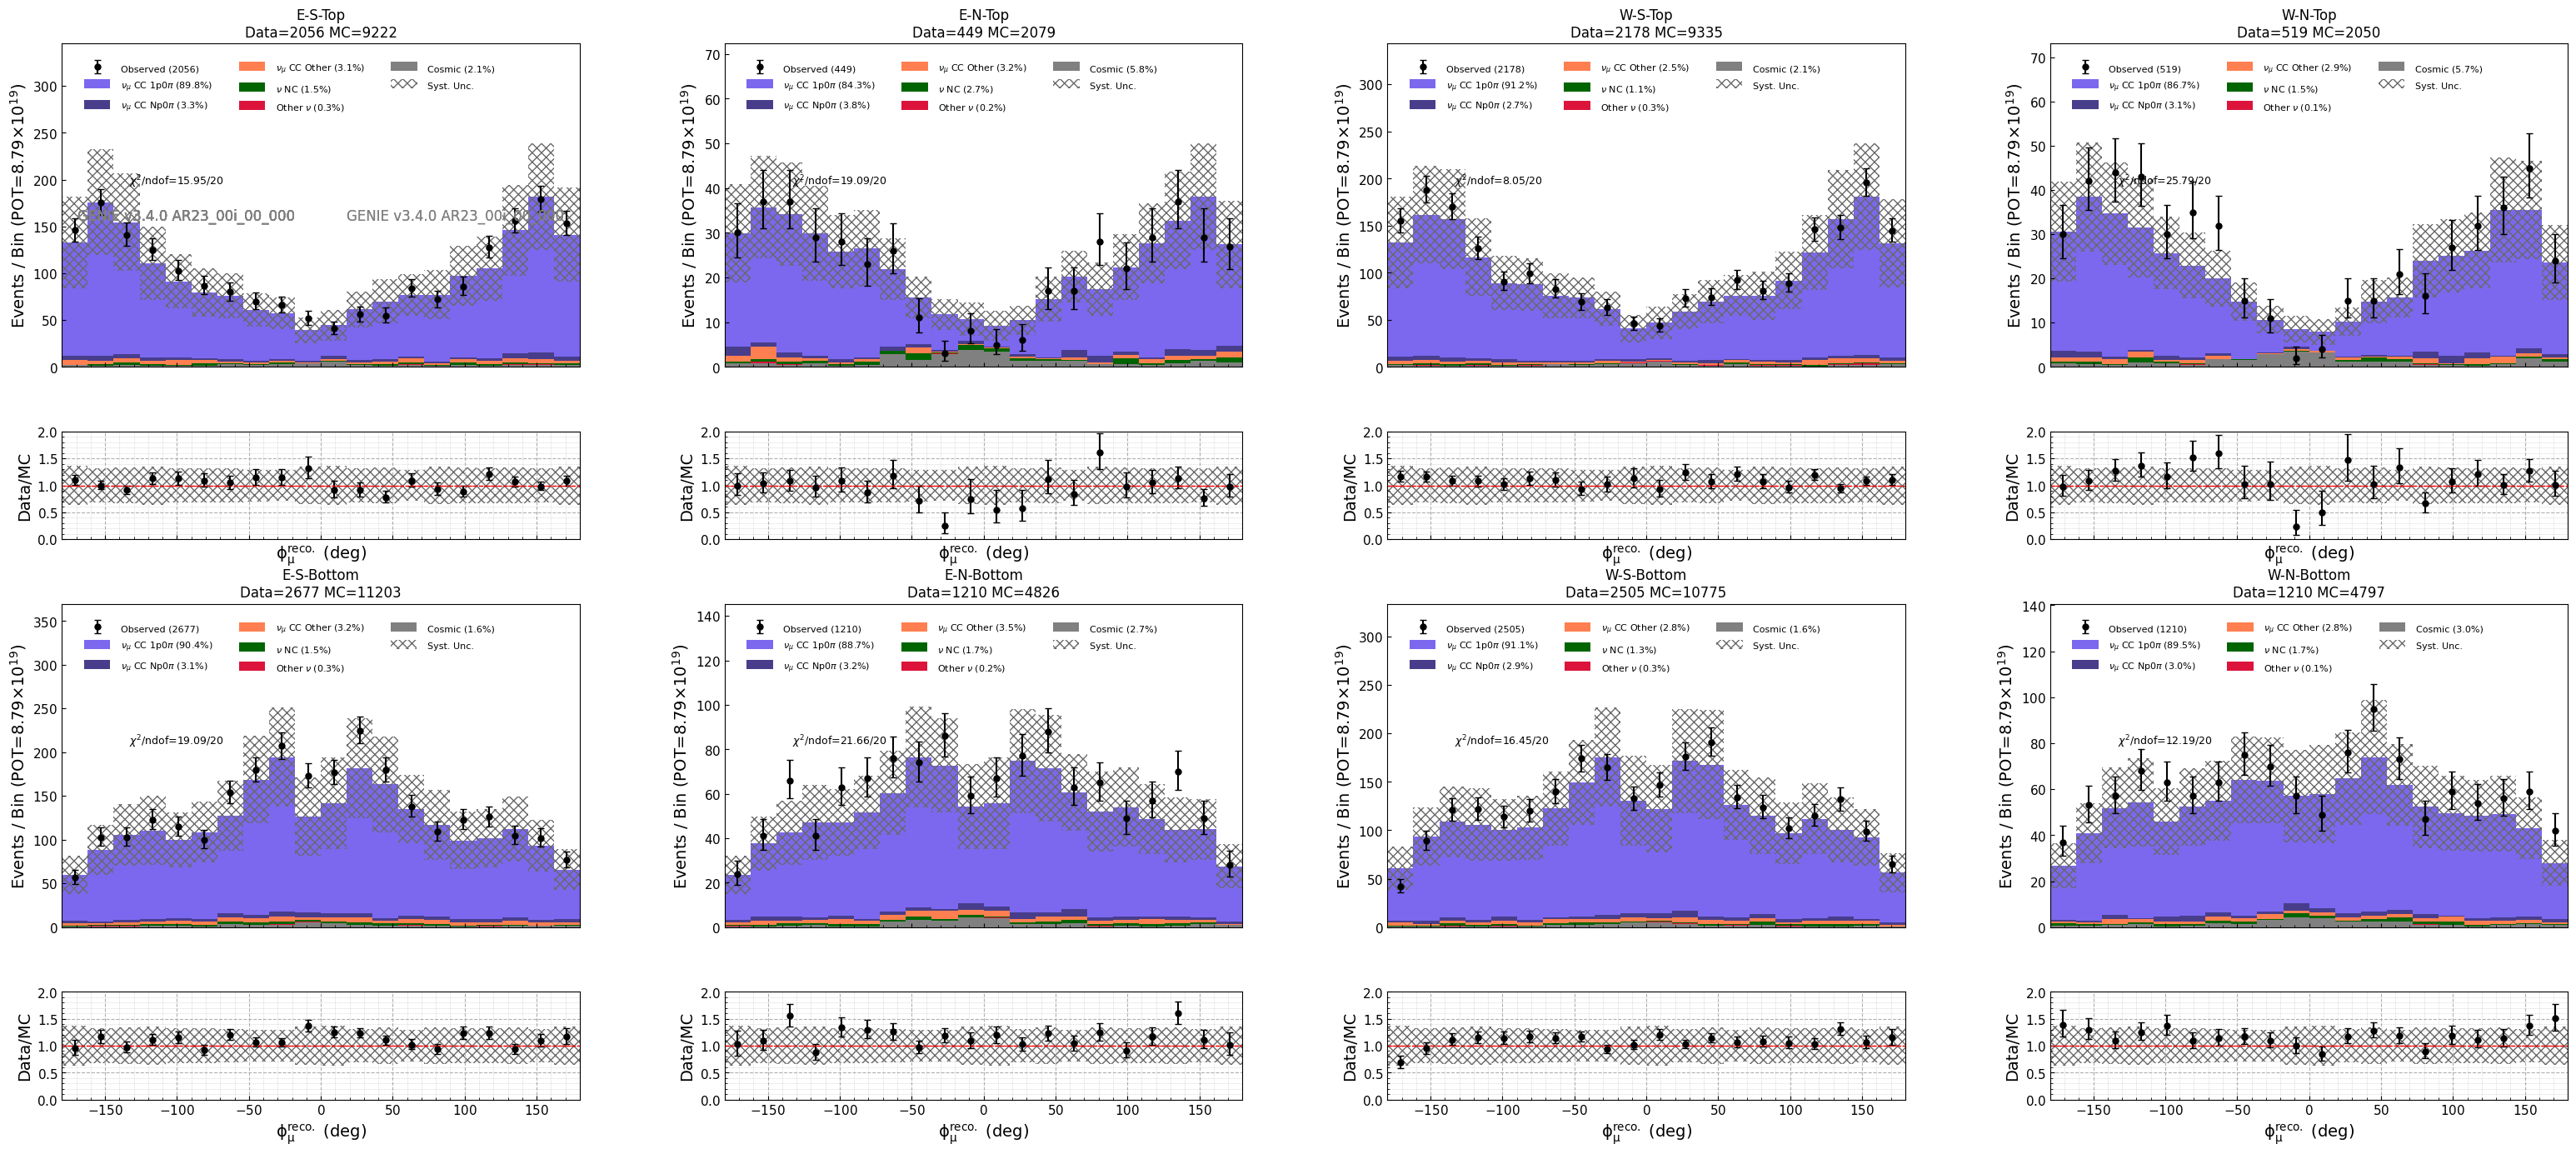

chi2     p_val  ndof  n_data   n_mc
var          octant                                              
muon-dir_phi E-S-Top     15.949909  0.719727    20    2056   9222
             E-N-Top     19.094889  0.515666    20     449   2079
             W-S-Top      8.054157  0.991503    20    2178   9335
             W-N-Top     25.793154  0.172753    20     519   2050
             E-S-Bottom  19.094142  0.515714    20    2677  11203
             E-N-Bottom  21.662007  0.359129    20    1210   4826
             W-S-Bottom  16.450513  0.688311    20    2505  10775
             W-N-Bottom  12.193035  0.909272    20    1210   4797

In [143]:
n_oct = len(_OCTANT_LABELS)
n_row_panels, n_cols = panel_grid_shape(n_oct)
n_gs_rows = 2 * n_row_panels  # rate + ratio row per panel row

chi2_spatial_all = []
for var_config in VAR_CONFIGS:
    fig_spatial, axes = plt.subplots(
        n_gs_rows, n_cols,
        figsize=homogeneity_figsize(n_row_panels, n_cols),
        sharex=True,
        gridspec_kw={
            "height_ratios": [3, 1] * n_row_panels,
            **HOMOGENEITY_GRIDSPEC,
        },
    )
    if n_cols == 1:
        axes = np.array(axes).reshape(n_gs_rows, 1)

    plotter = make_data_vs_mc_plotter(var_config, mc_evt_df, intime_evt_df)
    chi2_spatial = []
    for j, oct_label in enumerate(_OCTANT_LABELS):
        row_p, col = divmod(j, n_cols)
        ax_rate = axes[2 * row_p, col]
        ax_ratio = axes[2 * row_p + 1, col]
        d_o = data_evt_df.loc[octant_mask(data_evt_df, oct_label)]
        m_o = mc_evt_df.loc[octant_mask(mc_evt_df, oct_label)]
        subtitle = f"{oct_label}\nData={len(d_o)} MC={len(m_o)}"
        ret = draw_overlay_panel(
            fig_spatial, ax_rate, ax_ratio, var_config, plotter,
            data_df=d_o, mc_df=m_o, intime_df=intime_evt_df,
            subtitle=subtitle, textchi2=True,
        )
        if ret.get("chi2_val") is not None:
            chi2_spatial.append({
                "var": var_config.var_save_name,
                "octant": oct_label,
                "chi2": ret["chi2_val"],
                "p_val": ret["p_val"],
                "ndof": ret["ndof"],
                "n_data": len(d_o),
                "n_mc": len(m_o),
            })
        if col == 0:
            ax_rate.set_ylabel(pot_label)
            ax_ratio.set_ylabel("Data/MC")
        ax_ratio.axhline(1.0, color="red", linestyle="--", linewidth=0.8)

    # hide unused axes in the last panel row
    for k in range(n_oct, n_row_panels * n_cols):
        row_p, col = divmod(k, n_cols)
        axes[2 * row_p, col].set_visible(False)
        axes[2 * row_p + 1, col].set_visible(False)

    # fig_spatial.suptitle(
        # f"{var_config.var_plot_name} data/MC by octant "
        # f"(split @ ({_X0},{_Y0},{_Z0}) cm)",
        # fontsize=16, y=0.995,
    # )
    fig_spatial.subplots_adjust(top=0.94, bottom=0.06, left=0.05, right=0.99)
    if save_fig:
        out = path.join(
            save_fig_dir,
            f"homogeneity_spatial_{var_config.var_save_name}_{BREAKDOWN_TYPE}",
        )
        fig_spatial.savefig(out + fig_ext, bbox_inches="tight", dpi=dpi)
        print("saved", out + fig_ext)
    plt.show()
    chi2_spatial_all.extend(chi2_spatial)

chi2_spatial_df = pd.DataFrame(chi2_spatial_all).set_index(["var", "octant"])
chi2_spatial_df

## Temporal homogeneity — 15 time slices (MC POT scaled per chunk)

In [144]:
N_TIME_SPLITS = 8
hdr_splits, evt_splits = split_data_time_chunks(data_hdr_df, data_evt_df, n_splits=N_TIME_SPLITS)

chunk_summary = []
for i, hdr_chunk in enumerate(hdr_splits):
    t_min = hdr_chunk["global_trigger_time"].min()
    t_max = hdr_chunk["global_trigger_time"].max()
    chunk_summary.append({
        "Chunk": i,
        "Hdr events": len(hdr_chunk),
        "Evt rows": len(evt_splits[i]),
        "Start (UTC)": pd.Timestamp(t_min, unit="ns", tz="UTC").strftime("%Y-%m-%d %H:%M"),
        "End (UTC)": pd.Timestamp(t_max, unit="ns", tz="UTC").strftime("%Y-%m-%d %H:%M"),
        "Duration (min)": round((t_max - t_min) / 60e9, 1),
        "POT": hdr_chunk["pot"].sum() * FOM_POT_SCALE,
    })
pd.DataFrame(chunk_summary).set_index("Chunk")

,Hdr events,Evt rows,Start (UTC),End (UTC),Duration (min),POT
Chunk,,,,,,
0,221741,1613,2025-02-13 21:11,2025-02-20 15:21,9730.4,1.114254e+19
1,221740,1630,2025-02-20 15:21,2025-02-26 15:38,8656.5,1.108705e+19
2,221740,1602,2025-02-26 15:38,2025-03-04 19:44,8886.4,1.115842e+19
3,221740,1539,2025-03-04 19:44,2025-03-13 12:15,12510.5,1.064857e+19
4,221740,1587,2025-03-13 12:15,2025-03-21 12:49,11553.9,1.055310e+19
5,221740,1703,2025-03-21 12:49,2025-03-28 00:55,9365.5,1.110657e+19
6,221740,1560,2025-03-28 00:55,2025-04-04 02:14,10158.8,1.112296e+19
7,221740,1570,2025-04-04 02:14,2025-04-10 18:36,9622.6,1.105885e+19


saved /exp/sbnd/data/users/munjung/plots/numucc1p0pi/homogeneity_20260522/homogeneity_temporal_muon-dir_phi_topology.png


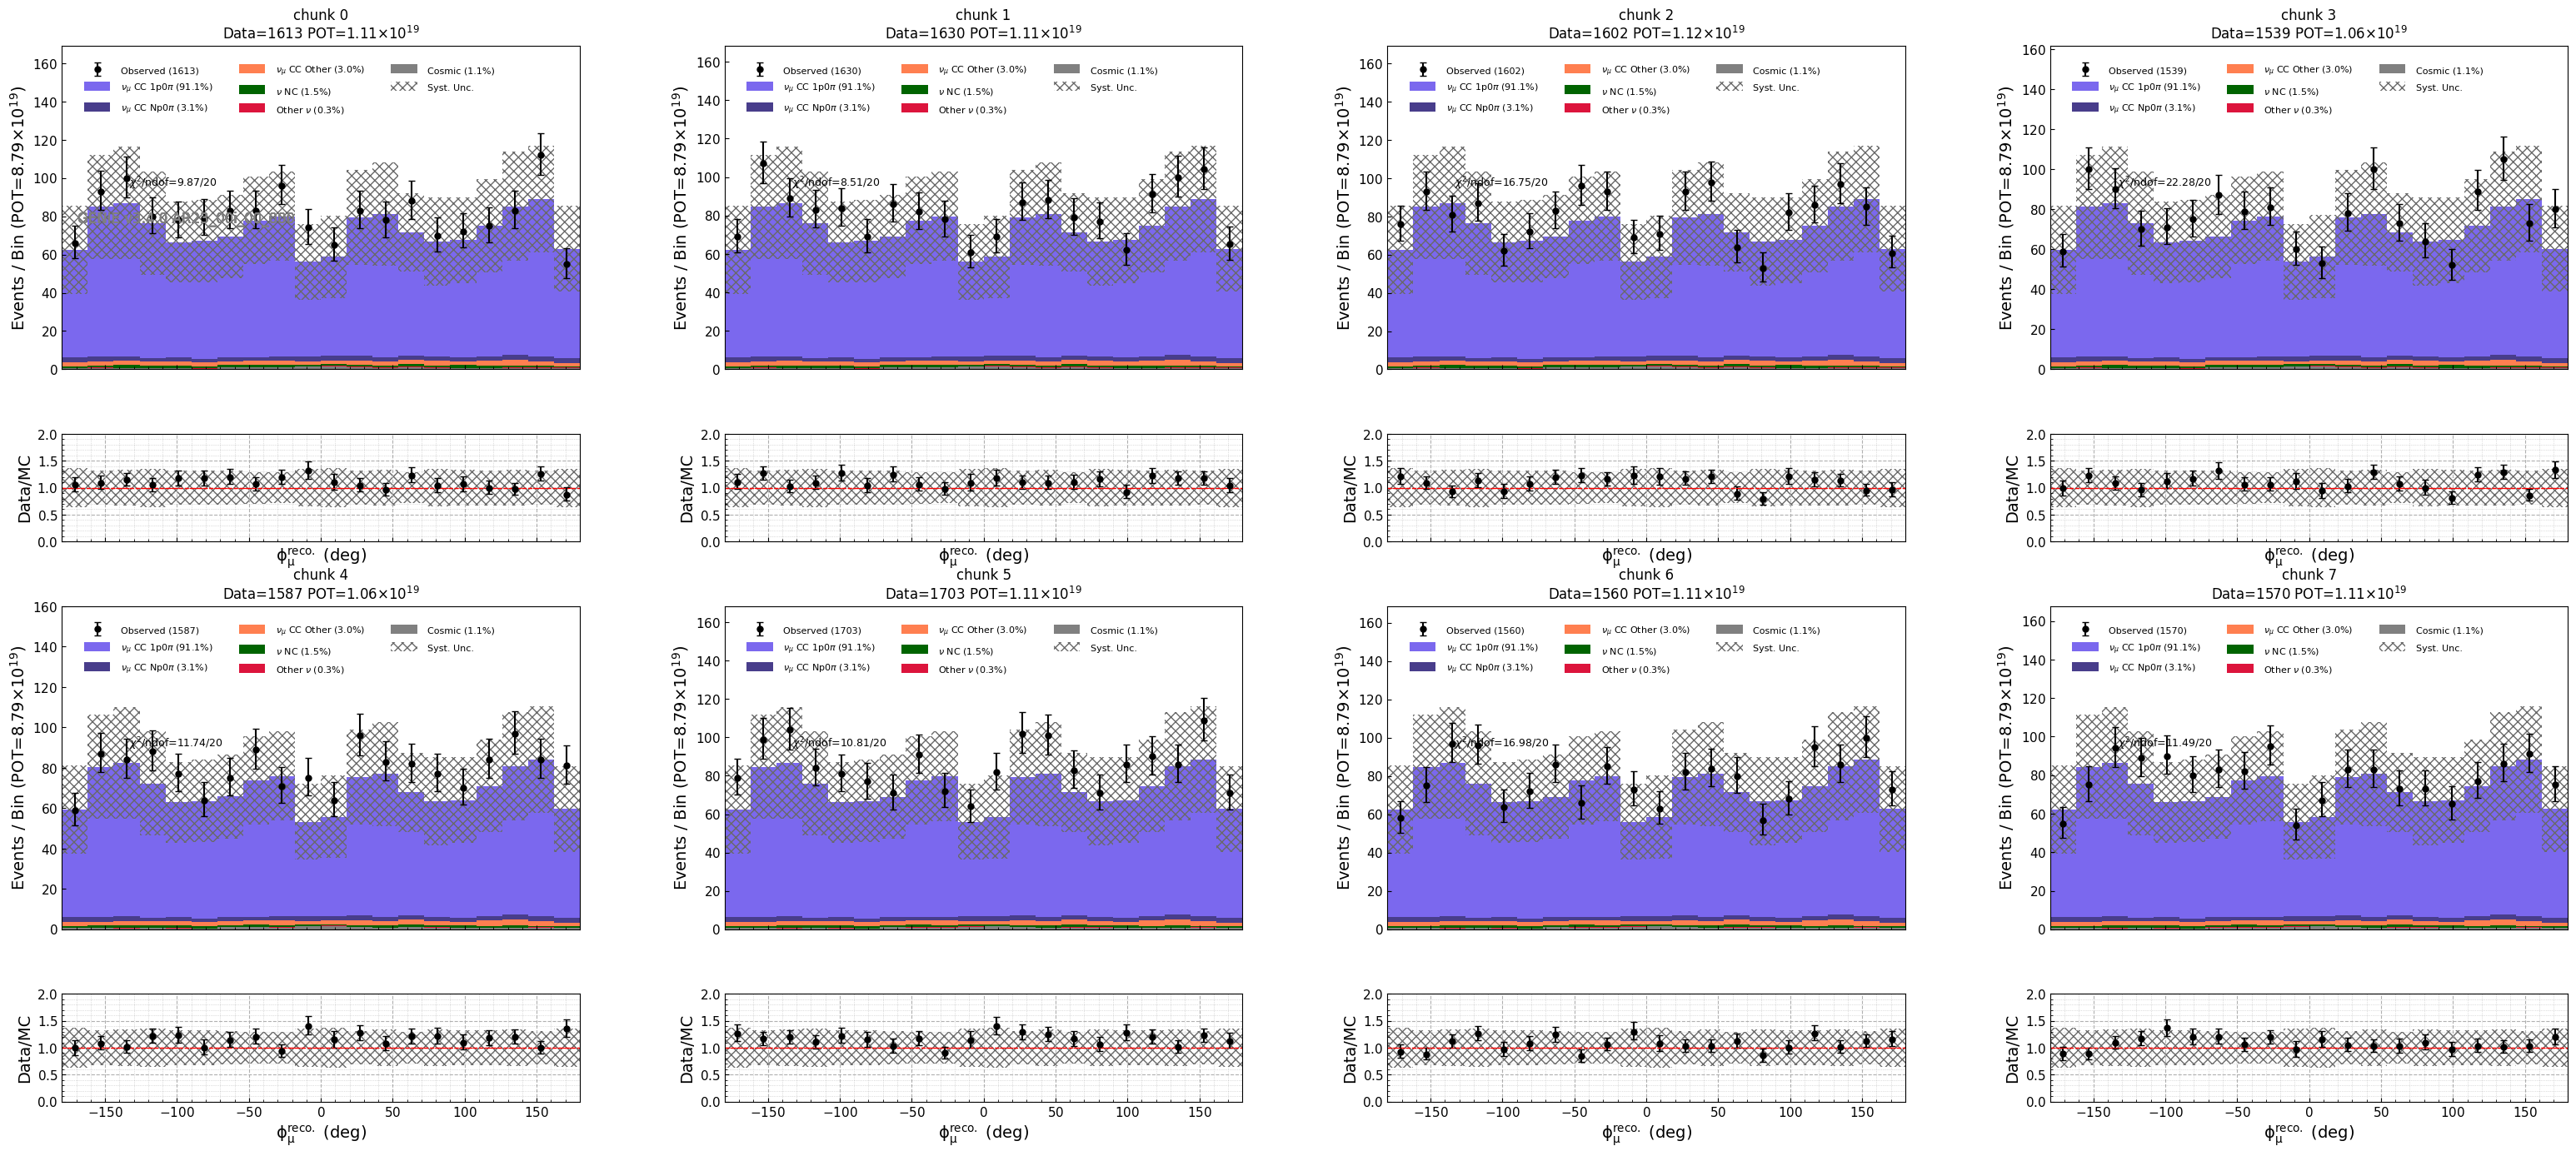

chi2     p_val  ndof  n_data     chunk_pot
var          chunk                                                 
muon-dir_phi 0       9.868176  0.970500    20    1613  1.114254e+19
             1       8.511506  0.987906    20    1630  1.108705e+19
             2      16.752440  0.668985    20    1602  1.115842e+19
             3      22.282608  0.325375    20    1539  1.064857e+19
             4      11.741142  0.924698    20    1587  1.055310e+19
             5      10.811792  0.950958    20    1703  1.110657e+19
             6      16.976998  0.654467    20    1560  1.112296e+19
             7      11.490402  0.932501    20    1570  1.105885e+19

In [145]:
n_row_panels, n_cols = panel_grid_shape(N_TIME_SPLITS)
n_gs_rows = 2 * n_row_panels

chi2_time_all = []
for var_config in VAR_CONFIGS:
    fig_time, axes = plt.subplots(
        n_gs_rows, n_cols,
        figsize=homogeneity_figsize(n_row_panels, n_cols),
        sharex=True,
        gridspec_kw={
            "height_ratios": [3, 1] * n_row_panels,
            **HOMOGENEITY_GRIDSPEC,
        },
    )
    if n_cols == 1:
        axes = np.array(axes).reshape(n_gs_rows, 1)

    chi2_time = []
    for i in range(N_TIME_SPLITS):
        row_p, col = divmod(i, n_cols)
        ax_rate = axes[2 * row_p, col]
        ax_ratio = axes[2 * row_p + 1, col]
        d_chunk = evt_splits[i]
        mc_chunk, intime_chunk, chunk_pot = mc_intime_for_chunk_pot(
            hdr_splits[i], mc_evt_df, intime_evt_df,
        )
        plotter = make_data_vs_mc_plotter(var_config, mc_chunk, intime_chunk)
        chunk_pot_str = get_pot_str(chunk_pot)
        subtitle = f"chunk {i}\nData={len(d_chunk)} POT={chunk_pot_str}"
        ret = draw_overlay_panel(
            fig_time, ax_rate, ax_ratio, var_config, plotter,
            data_df=d_chunk, mc_df=mc_chunk, intime_df=intime_chunk,
            subtitle=subtitle, textchi2=True,
        )
        if ret.get("chi2_val") is not None:
            chi2_time.append({
                "var": var_config.var_save_name,
                "chunk": i,
                "chi2": ret["chi2_val"],
                "p_val": ret["p_val"],
                "ndof": ret["ndof"],
                "n_data": len(d_chunk),
                "chunk_pot": chunk_pot,
            })
        ax_ratio.axhline(1.0, color="red", linestyle="--", linewidth=0.8)
        if col == 0:
            ax_rate.set_ylabel(pot_label)
            ax_ratio.set_ylabel("Data/MC")

    for k in range(N_TIME_SPLITS, n_row_panels * n_cols):
        row_p, col = divmod(k, n_cols)
        axes[2 * row_p, col].set_visible(False)
        axes[2 * row_p + 1, col].set_visible(False)

    # fig_time.suptitle(
    #     f"{var_config.var_plot_name} data/MC vs time chunk "
    #     f"({N_TIME_SPLITS} slices, MC POT scaled per chunk)",
    #     fontsize=16, y=0.995,
    # )
    fig_time.subplots_adjust(top=0.94, bottom=0.06, left=0.05, right=0.99)
    if save_fig:
        out = path.join(
            save_fig_dir,
            f"homogeneity_temporal_{var_config.var_save_name}_{BREAKDOWN_TYPE}",
        )
        fig_time.savefig(out + fig_ext, bbox_inches="tight", dpi=dpi)
        print("saved", out + fig_ext)
    plt.show()
    chi2_time_all.extend(chi2_time)

chi2_time_df = pd.DataFrame(chi2_time_all).set_index(["var", "chunk"])
chi2_time_df